In [ ]:
# !pip install --upgrade tensorflow imbalanced-learn scikit-learn shap "protobuf>=6.31.1" -q

In [ ]:
# ============================================================
# BLOCK 1 — SETUP (LSTM)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("GPU available:", tf.config.list_physical_devices('GPU'))
if not tf.config.list_physical_devices('GPU'):
    print("WARNING: no GPU detected — go to Runtime > Change runtime type > T4 GPU before continuing.")

# from google.colab import drive
# drive.mount('/content/drive')

X_SEQ_PATH = "/content/drive/MyDrive/sadman_works/additional_r&d/dataset/X_seq.npy"
Y_SEQ_PATH = "/content/drive/MyDrive/sadman_works/additional_r&d/dataset/y_seq.npy"
META_PATH  = "/content/drive/MyDrive/sadman_works/additional_r&d/dataset/seq_meta.csv"

X_seq = np.load(X_SEQ_PATH)
y_seq = np.load(Y_SEQ_PATH)
seq_meta = pd.read_csv(META_PATH)

print("X_seq shape:", X_seq.shape, " (n_sequences, seq_len, n_features)")
print("y_seq shape:", y_seq.shape)
print("y_seq unique values:", np.unique(y_seq))
print("\nseq_meta shape:", seq_meta.shape)
print("seq_meta columns:", list(seq_meta.columns))
print(seq_meta.head())

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
X_seq shape: (918847, 20, 18)  (n_sequences, seq_len, n_features)
y_seq shape: (918847,)
y_seq unique values: [0 1 3]

seq_meta shape: (918847, 3)
seq_meta columns: ['trading_code', 'date', 'split']
  trading_code        date  split
0     AAMRANET  2017-11-23  train
1     AAMRANET  2017-11-26  train
2     AAMRANET  2017-11-27  train
3     AAMRANET  2017-11-28  train
4     AAMRANET  2017-11-29  train


In [ ]:
# ============================================================
# BLOCK 2 — FEATURES / TARGET / TRAIN-TEST SPLIT (sequence-aligned)
# ASSUMPTION (confirm against Block 1 output): seq_meta has columns
# ['trading_code','date','split','target_class'], row-aligned 1:1 with
# X_seq/y_seq (row i of seq_meta corresponds to X_seq[i], y_seq[i]).
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]
assert X_seq.shape[-1] == len(ALL_FEATURES), \
    f"X_seq has {X_seq.shape[-1]} features, expected {len(ALL_FEATURES)} — check feature order/list."
assert len(seq_meta) == len(X_seq) == len(y_seq), "seq_meta / X_seq / y_seq row counts don't match."

LABEL_MAP   = {0: 0, 1: 1, 3: 2}
CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}
CRASH_IDX   = 2

# Remap y_seq to {0,1,2} only if it's still in original {0,1,3} form
if set(np.unique(y_seq)) <= {0, 1, 3}:
    y_seq_mapped = np.vectorize(LABEL_MAP.get)(y_seq)
else:
    y_seq_mapped = y_seq.copy()
assert set(np.unique(y_seq_mapped)) <= {0, 1, 2}, "Unexpected label values after remapping."

seq_meta["y"] = y_seq_mapped

train_mask = (seq_meta["split"] == "train").values
test_mask  = (seq_meta["split"] == "test").values

X_train_seq, y_train_seq = X_seq[train_mask], y_seq_mapped[train_mask]
X_test_seq,  y_test_seq  = X_seq[test_mask],  y_seq_mapped[test_mask]

train_meta = seq_meta[train_mask].reset_index(drop=True)
test_meta  = seq_meta[test_mask].reset_index(drop=True)

print("Train sequences:", X_train_seq.shape, " Test sequences:", X_test_seq.shape)
print("Train class balance:", np.round(np.bincount(y_train_seq) / len(y_train_seq), 4))
print("Test  class balance:", np.round(np.bincount(y_test_seq) / len(y_test_seq), 4))

Train sequences: (624454, 20, 18)  Test sequences: (294393, 20, 18)
Train class balance: [0.7403 0.2046 0.0552]
Test  class balance: [0.7379 0.215  0.0471]


In [ ]:
# ============================================================
# BLOCK 4 — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO (sequences)
# Same logic as the tabular models, applied to sequence target dates.
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

train_meta["date"] = pd.to_datetime(train_meta["date"])
unique_train_dates = np.sort(train_meta["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_meta["date"].values
cv_splits_seq = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits_seq.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} seqs) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} seqs)")

Fold 1: train 2008-05-04->2010-02-02 (80,616 seqs) | val 2010-02-10->2011-11-28 (89,975 seqs)
Fold 2: train 2008-05-04->2011-11-21 (170,519 seqs) | val 2011-11-29->2013-09-16 (96,727 seqs)
Fold 3: train 2008-05-04->2013-09-09 (267,141 seqs) | val 2013-09-17->2015-06-28 (108,131 seqs)
Fold 4: train 2008-05-04->2015-06-21 (375,098 seqs) | val 2015-06-29->2017-03-28 (120,340 seqs)
Fold 5: train 2008-05-04->2017-03-20 (495,362 seqs) | val 2017-03-29->2018-12-23 (126,717 seqs)


In [ ]:
# ============================================================
# BLOCK 5-GRU — SCORER + MODEL ARCHITECTURE BUILDER
# ============================================================
from tensorflow.keras.layers import GRU

def crash_pr_auc(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

def macro_pr_auc(y_true, y_proba):
    return np.mean([average_precision_score((y_true == c).astype(int), y_proba[:, c])
                     for c in range(3)])

def build_gru(input_shape, units1=64, units2=32, dropout=0.3, lr=1e-3):
    model = Sequential([
        GRU(units1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout),
        GRU(units2),
        Dropout(dropout),
        Dense(16, activation="relu"),
        Dense(3, activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def get_class_weight_dict(y):
    classes = np.unique(y)
    weights = compute_class_weight("balanced", classes=classes, y=y)
    return dict(zip(classes, weights))

print("Scorers and GRU model builder ready.")

Scorers and GRU model builder ready.


In [ ]:
# ============================================================
# BLOCK 6-GRU — SCORERS (make_scorer objects, for consistency)
# ============================================================
from sklearn.metrics import make_scorer

crash_scorer = make_scorer(crash_pr_auc, response_method="predict_proba")
macro_scorer = make_scorer(macro_pr_auc, response_method="predict_proba")

print("Scorers ready: crash_pr_auc / macro_pr_auc (plain functions), crash_scorer / macro_scorer (make_scorer objects).")

Scorers ready: crash_pr_auc / macro_pr_auc (plain functions), crash_scorer / macro_scorer (make_scorer objects).


In [ ]:
# ============================================================
# BLOCK 7-GRU — HYPERPARAMETER SEARCH (single validation fold, 4 candidates)
# ============================================================
tr_idx_search, va_idx_search = cv_splits_seq[-1]   # last (largest) fold for tuning
X_tr_s, y_tr_s = X_train_seq[tr_idx_search], y_train_seq[tr_idx_search]
X_va_s, y_va_s = X_train_seq[va_idx_search], y_train_seq[va_idx_search]
cw = get_class_weight_dict(y_tr_s)

CANDIDATES = [
    {"units1": 64, "units2": 32, "dropout": 0.2, "lr": 1e-3, "batch_size": 256},
    {"units1": 64, "units2": 32, "dropout": 0.3, "lr": 1e-3, "batch_size": 256},
    {"units1": 64, "units2": 32, "dropout": 0.3, "lr": 5e-4, "batch_size": 256},
    {"units1": 64, "units2": 32, "dropout": 0.4, "lr": 5e-4, "batch_size": 256},
]

results_gru = []
for i, cand in enumerate(CANDIDATES):
    print(f"\n--- Candidate {i+1}/{len(CANDIDATES)}: {cand} ---")
    t0 = time.time()
    model = build_gru(input_shape=(X_tr_s.shape[1], X_tr_s.shape[2]),
                       units1=cand["units1"], units2=cand["units2"],
                       dropout=cand["dropout"], lr=cand["lr"])
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr_s, y_tr_s, validation_data=(X_va_s, y_va_s),
              epochs=20, batch_size=cand["batch_size"], class_weight=cw,
              callbacks=[es], verbose=0)
    proba = model.predict(X_va_s, verbose=0)
    score = crash_pr_auc(y_va_s, proba)
    elapsed = time.time() - t0
    print(f"  crash_PR-AUC={score:.4f}  ({elapsed:.0f}s)")
    results_gru.append({**cand, "crash_pr_auc": score, "time_s": elapsed})

results_df_gru = pd.DataFrame(results_gru).sort_values("crash_pr_auc", ascending=False)
print("\n=== CANDIDATE RESULTS ===")
print(results_df_gru)

best_params_gru = results_df_gru.iloc[0][["units1","units2","dropout","lr","batch_size"]].to_dict()
best_params_gru["units1"] = int(best_params_gru["units1"])
best_params_gru["units2"] = int(best_params_gru["units2"])
best_params_gru["batch_size"] = int(best_params_gru["batch_size"])
print("\n=== BEST PARAMS ===")
print(best_params_gru)


--- Candidate 1/4: {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 256} ---
  crash_PR-AUC=0.1403  (121s)

--- Candidate 2/4: {'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 256} ---
  crash_PR-AUC=0.1558  (189s)

--- Candidate 3/4: {'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.0005, 'batch_size': 256} ---
  crash_PR-AUC=0.1391  (131s)

--- Candidate 4/4: {'units1': 64, 'units2': 32, 'dropout': 0.4, 'lr': 0.0005, 'batch_size': 256} ---
  crash_PR-AUC=0.1323  (190s)

=== CANDIDATE RESULTS ===
   units1  units2  dropout      lr  batch_size  crash_pr_auc      time_s
1      64      32      0.3  0.0010         256      0.155798  189.474879
0      64      32      0.2  0.0010         256      0.140308  120.511903
2      64      32      0.3  0.0005         256      0.139102  131.272081
3      64      32      0.4  0.0005         256      0.132273  190.015860

=== BEST PARAMS ===
{'units1': 64, 'units2': 32, 'dropout': 0.3, 'lr': 0.001, 'ba

In [ ]:
# ============================================================
# BLOCK 8-GRU — CV FOLD-LEVEL METRICS WITH FINAL ARCHITECTURE
# ============================================================
model_build_params_gru = {k: v for k, v in best_params_gru.items() if k != "batch_size"}
batch_size_final_gru = best_params_gru["batch_size"]

fold_metrics_gru = []
for i, (tr_idx, va_idx) in enumerate(cv_splits_seq):
    X_tr, y_tr = X_train_seq[tr_idx], y_train_seq[tr_idx]
    X_va, y_va = X_train_seq[va_idx], y_train_seq[va_idx]
    cw_fold = get_class_weight_dict(y_tr)

    model = build_gru(input_shape=(X_tr.shape[1], X_tr.shape[2]), **model_build_params_gru)
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=20, batch_size=batch_size_final_gru, class_weight=cw_fold,
              callbacks=[es], verbose=0)

    proba = model.predict(X_va, verbose=0)
    pred = proba.argmax(axis=1)

    fold_metrics_gru.append({
        "fold": i + 1,
        "crash_pr_auc": crash_pr_auc(y_va, proba),
        "macro_pr_auc": macro_pr_auc(y_va, proba),
        "crash_recall": recall_score(y_va == CRASH_IDX, pred == CRASH_IDX),
        "crash_precision": precision_score(y_va == CRASH_IDX, pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_va, proba, multi_class="ovr"),
    })
    print(f"Fold {i+1} done — crash_PR-AUC={fold_metrics_gru[-1]['crash_pr_auc']:.4f}")

fold_df_gru = pd.DataFrame(fold_metrics_gru).set_index("fold")
print(fold_df_gru.round(4))
print("\nMean ± Std across folds:")
print((fold_df_gru.mean().round(4).astype(str) + " ± " + fold_df_gru.std().round(4).astype(str)))

Fold 1 done — crash_PR-AUC=0.1478
Fold 2 done — crash_PR-AUC=0.1215
Fold 3 done — crash_PR-AUC=0.1037
Fold 4 done — crash_PR-AUC=0.1446
Fold 5 done — crash_PR-AUC=0.1406
      crash_pr_auc  macro_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                                        
1           0.1478        0.4610        0.2365           0.1677       0.6918
2           0.1215        0.4603        0.2591           0.1330       0.6910
3           0.1037        0.4590        0.1476           0.1134       0.7267
4           0.1446        0.4765        0.1485           0.1806       0.7731
5           0.1406        0.4705        0.2991           0.1430       0.7645

Mean ± Std across folds:
crash_pr_auc       0.1316 ± 0.0187
macro_pr_auc       0.4655 ± 0.0077
crash_recall       0.2181 ± 0.0678
crash_precision    0.1476 ± 0.0269
roc_auc_ovr        0.7294 ± 0.0388
dtype: object


Epoch 1/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.5440 - loss: 1.0117
Epoch 2/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5725 - loss: 0.9807
Epoch 3/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5791 - loss: 0.9696
Epoch 4/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5831 - loss: 0.9630
Epoch 5/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5891 - loss: 0.9599
Epoch 6/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5886 - loss: 0.9582
Epoch 7/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5916 - loss: 0.9547
Epoch 8/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5944 - loss: 0.9540
Epoch 9/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.5958 - loss: 0.9526
Epoch 10/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.5964 - loss: 0.9506
Epoch 11/25
2440/2440 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.6002 - loss: 0.9483
Epoch 12/25
2440/24

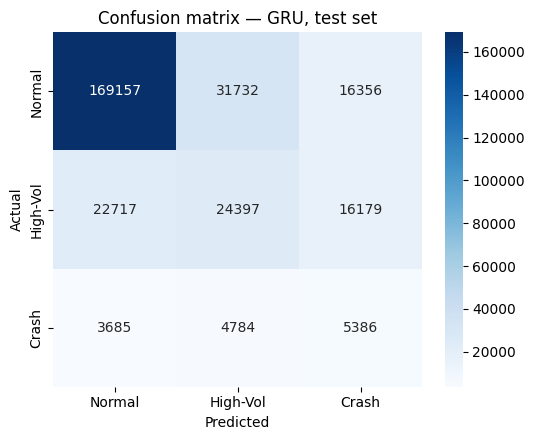


Crash-class PR-AUC : 0.1407
Macro PR-AUC       : 0.4919
ROC-AUC (OvR)      : 0.7751


In [ ]:
# ============================================================
# BLOCK 9-GRU — FINAL MODEL: fit on full train, evaluate on held-out test
# ============================================================
cw_full = get_class_weight_dict(y_train_seq)

model_params_gru = {k: v for k, v in best_params_gru.items() if k != "batch_size"}
batch_size_gru = best_params_gru.get("batch_size", 32)

final_model_gru = build_gru(input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), **model_params_gru)
es = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
history_gru = final_model_gru.fit(X_train_seq, y_train_seq, epochs=25,
                                   batch_size=batch_size_gru,
                                   class_weight=cw_full, callbacks=[es], verbose=1)

test_proba_gru = final_model_gru.predict(X_test_seq, verbose=0)
test_pred_gru  = test_proba_gru.argmax(axis=1)

print("=== Classification report (test set) — GRU ===")
print(classification_report(y_test_seq, test_pred_gru, target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm_gru = confusion_matrix(y_test_seq, test_pred_gru)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_gru, annot=True, fmt="d", cmap="Blues",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — GRU, test set")
plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc(y_test_seq, test_proba_gru):.4f}")
print(f"Macro PR-AUC       : {macro_pr_auc(y_test_seq, test_proba_gru):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test_seq, test_proba_gru, multi_class='ovr'):.4f}")

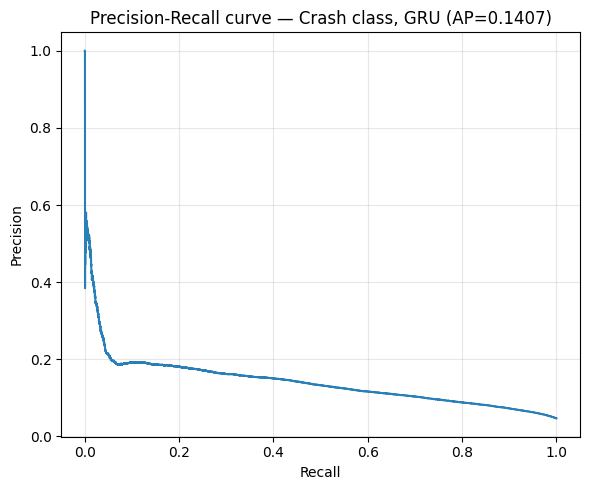

Recall @ FPR<=5%: 0.2188  (threshold=0.4993)
Precision@top-50 alerts: 0.5400
Precision@top-100 alerts: 0.5500
Precision@top-500 alerts: 0.4100
Precision@top-1000 alerts: 0.3420

Event-level crash recall (±1 day tolerance): 0.5505  (11451 distinct crash episodes)


In [ ]:
# ============================================================
# BLOCK 10-GRU — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# ============================================================
prec_g, rec_g, _ = precision_recall_curve(y_test_seq == CRASH_IDX, test_proba_gru[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec_g, prec_g, color="#2980b9")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, GRU "
          f"(AP={average_precision_score(y_test_seq==CRASH_IDX, test_proba_gru[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

fpr_g, tpr_g, roc_thresh_g = roc_curve(y_test_seq == CRASH_IDX, test_proba_gru[:, CRASH_IDX])
target_fpr = 0.05
idx = max(np.searchsorted(fpr_g, target_fpr, side="right") - 1, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr_g[idx]:.4f}  (threshold={roc_thresh_g[idx]:.4f})")

for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba_gru[:, CRASH_IDX])[:k]
    prec_at_k = (y_test_seq[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

def event_level_recall_seq(meta_df, y_true, y_pred, tolerance=1):
    tdf = meta_df.copy()
    tdf["y_true"] = y_true
    tdf["y_pred"] = y_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

ev_recall_gru, n_events_gru = event_level_recall_seq(test_meta, y_test_seq, test_pred_gru, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall_gru:.4f}  ({n_events_gru} distinct crash episodes)")

Brier score (crash)                       : 0.08314
Brier score, prevalence-only baseline     : 0.04485
Brier Skill Score vs. prevalence baseline : -0.8538


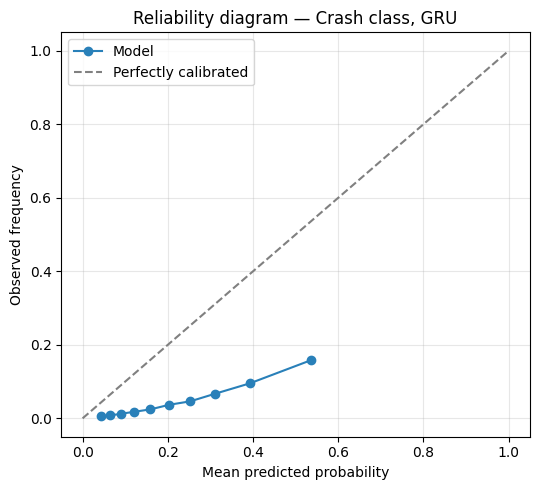


Expected Calibration Error (crash): 0.1703


In [ ]:
# ============================================================
# BLOCK 11-GRU — CALIBRATION DIAGNOSTICS
# ============================================================
y_crash_true = (y_test_seq == CRASH_IDX).astype(int)
p_crash_gru = test_proba_gru[:, CRASH_IDX]

brier_gru = brier_score_loss(y_crash_true, p_crash_gru)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash_gru, prevalence))
brier_skill_score_gru = 1 - (brier_gru / brier_baseline)

print(f"Brier score (crash)                       : {brier_gru:.5f}")
print(f"Brier score, prevalence-only baseline     : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline : {brier_skill_score_gru:.4f}")

frac_pos_g, mean_pred_g = calibration_curve(y_crash_true, p_crash_gru, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred_g, frac_pos_g, marker="o", color="#2980b9", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, GRU")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(p_crash_gru, bins) - 1
ece_gru = 0.0
for b in range(10):
    mask = bin_ids == b
    if mask.sum() == 0: continue
    ece_gru += (mask.sum() / len(p_crash_gru)) * abs(y_crash_true[mask].mean() - p_crash_gru[mask].mean())
print(f"\nExpected Calibration Error (crash): {ece_gru:.4f}")

In [ ]:
# ============================================================
# BLOCK 12-GRU — REGIME-SPECIFIC PERFORMANCE
# ============================================================
REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

test_meta_eval_gru = test_meta.copy()
test_meta_eval_gru["date"] = pd.to_datetime(test_meta_eval_gru["date"])
test_meta_eval_gru["y_true"] = y_test_seq
test_meta_eval_gru["y_pred"] = test_pred_gru
test_meta_eval_gru["p_crash"] = test_proba_gru[:, CRASH_IDX]

regime_rows_gru = []
for name, (start, end) in REGIMES.items():
    mask = (test_meta_eval_gru["date"] >= start) & (test_meta_eval_gru["date"] <= end)
    sub = test_meta_eval_gru[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows_gru.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df_gru = pd.DataFrame(regime_rows_gru).set_index("regime")
print(regime_df_gru.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        88045      0.0521        0.3431           0.1439   
COVID crash              6099      0.2289        0.4907           0.2596   
Post-COVID recovery    123425      0.0472        0.4109           0.1297   
Russia-Ukraine (2022)   64780      0.0262        0.3716           0.1210   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.1472  
COVID crash                  0.2623  
Post-COVID recovery          0.1320  
Russia-Ukraine (2022)        0.1122  


In [ ]:
# ============================================================
# BLOCK 13-GRU — CUSTOM PERMUTATION IMPORTANCE (sequence-aware)
# ============================================================
LABEL_ADJACENT = ["daily_return", "intraday_volatility"]

def permutation_importance_seq(model, X, y_true, feature_names, n_repeats=3, random_state=42):
    rng = np.random.RandomState(random_state)
    baseline_proba = model.predict(X, verbose=0)
    baseline_score = crash_pr_auc(y_true, baseline_proba)

    results = []
    for f_idx, fname in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm_order = rng.permutation(X_perm.shape[0])
            X_perm[:, :, f_idx] = X_perm[perm_order, :, f_idx]
            proba_perm = model.predict(X_perm, verbose=0)
            drops.append(baseline_score - crash_pr_auc(y_true, proba_perm))
        results.append({"feature": fname, "importance_mean": np.mean(drops), "importance_std": np.std(drops)})
    return pd.DataFrame(results)

subsample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test_seq), min(10000, len(X_test_seq)), replace=False)
X_test_sub = X_test_seq[subsample_idx]
y_test_sub = y_test_seq[subsample_idx]

perm_df_gru = permutation_importance_seq(final_model_gru, X_test_sub, y_test_sub, ALL_FEATURES, n_repeats=3)
perm_df_gru["label_adjacent"] = perm_df_gru["feature"].isin(LABEL_ADJACENT)
perm_df_gru = perm_df_gru.sort_values("importance_mean", ascending=False)

print("="*70)
print("PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test subsample) — GRU")
print("="*70)
print(perm_df_gru.round(5))
print("\n(Interpret as associational, not causal — Reviewer 4.)")

PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test subsample) — GRU
                  feature  importance_mean  importance_std  label_adjacent
2     intraday_volatility          0.05873         0.00623            True
12                stoch_k          0.05419         0.00116           False
13                stoch_d          0.01355         0.00389           False
11                 rsi_14          0.00696         0.00475           False
14                 roc_10          0.00500         0.00147           False
3       volume_change_pct          0.00318         0.00258           False
17                    obv          0.00313         0.00042           False
7                  ema_12          0.00311         0.00246           False
4               price_gap          0.00229         0.00142           False
5   rolling_5d_volatility          0.00163         0.00089           False
8                    macd          0.00097         0.00060           False
10              macd_hist    

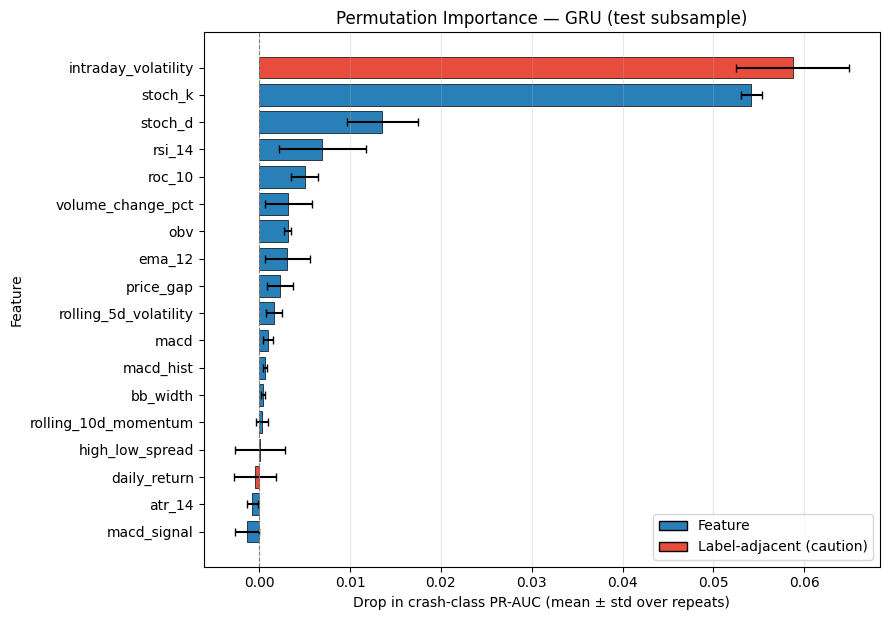

In [ ]:
# ============================================================
# BLOCK 13-GRU (continued) — PLOT: Permutation Importance
# ============================================================
plt.figure(figsize=(9, max(4, 0.35 * len(perm_df_gru))))

plot_df = perm_df_gru.sort_values("importance_mean", ascending=True)
colors = ["#e74c3c" if adj else "#2980b9" for adj in plot_df["label_adjacent"]]

plt.barh(plot_df["feature"], plot_df["importance_mean"],
         xerr=plot_df["importance_std"], color=colors,
         edgecolor="black", linewidth=0.5, capsize=3)

plt.axvline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Drop in crash-class PR-AUC (mean ± std over repeats)")
plt.ylabel("Feature")
plt.title("Permutation Importance — GRU (test subsample)")

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor="#2980b9", edgecolor="black", label="Feature"),
    Patch(facecolor="#e74c3c", edgecolor="black", label="Label-adjacent (caution)")
]
plt.legend(handles=legend_elems, loc="lower right")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOCK 14-GRU — SMOTE VARIANT (flatten sequences, SMOTE, reshape back)
# ============================================================
n_samples, seq_len, n_feat = X_train_seq.shape
X_train_flat = X_train_seq.reshape(n_samples, seq_len * n_feat)

X_res_flat_gru, y_res_gru = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_flat, y_train_seq)
X_res_seq_gru = X_res_flat_gru.reshape(-1, seq_len, n_feat)

print(f"Original class counts: {np.bincount(y_train_seq)}")
print(f"SMOTE-resampled class counts: {np.bincount(y_res_gru)}")

model_params_gru = {k: v for k, v in best_params_gru.items() if k != "batch_size"}
batch_size_gru = best_params_gru.get("batch_size", 32)

model_smote_gru = build_gru(input_shape=(seq_len, n_feat), **model_params_gru)
es = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
model_smote_gru.fit(X_res_seq_gru, y_res_gru, epochs=20, batch_size=batch_size_gru,
                     callbacks=[es], verbose=1)

smote_test_proba_gru = model_smote_gru.predict(X_test_seq, verbose=0)
print(f"\n[SMOTE variant]        crash PR-AUC (test): {crash_pr_auc(y_test_seq, smote_test_proba_gru):.4f}")
print(f"[Class-weight variant] crash PR-AUC (test): {crash_pr_auc(y_test_seq, test_proba_gru):.4f}")

Original class counts: [462265 127738  34451]
SMOTE-resampled class counts: [462265 462265 462265]
Epoch 1/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 38s 7ms/step - accuracy: 0.5606 - loss: 0.8715
Epoch 2/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6053 - loss: 0.8006
Epoch 3/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6176 - loss: 0.7810
Epoch 4/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6244 - loss: 0.7696
Epoch 5/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6298 - loss: 0.7607
Epoch 6/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - accuracy: 0.6343 - loss: 0.7536
Epoch 7/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6371 - loss: 0.7486
Epoch 8/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6402 - loss: 0.7436
Epoch 9/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6419 - loss: 0.7404
Epoch 10/20
5418/5418 ━━━━━━━━━━━━━━━━━━━━ 36s 7ms/step - accuracy: 0.6442 - loss: 0.7361
Epoch 11/2

In [ ]:
# ============================================================
# BLOCK 15-GRU — SUMMARY TABLE
# ============================================================
summary_gru = pd.DataFrame({
    "Model": ["GRU (class-weighted)", "GRU (SMOTE)"],
    "Crash PR-AUC": [
        crash_pr_auc(y_test_seq, test_proba_gru),
        crash_pr_auc(y_test_seq, smote_test_proba_gru),
    ],
    "Crash Recall": [
        recall_score(y_test_seq==CRASH_IDX, test_pred_gru==CRASH_IDX),
        recall_score(y_test_seq==CRASH_IDX, smote_test_proba_gru.argmax(axis=1)==CRASH_IDX),
    ],
})
print(summary_gru.round(4))

                  Model  Crash PR-AUC  Crash Recall
0  GRU (class-weighted)        0.1407        0.3887
1           GRU (SMOTE)        0.1291        0.1151


1. CLASSIFICATION REPORT (test set) — GRU
              precision  recall  f1-score      support
Normal           0.8650  0.7786    0.8196  217245.0000
High-Vol         0.4005  0.3855    0.3928   63293.0000
Crash            0.1420  0.3887    0.2081   13855.0000
accuracy         0.6758  0.6758    0.6758       0.6758
macro avg        0.4692  0.5176    0.4735  294393.0000
weighted avg     0.7311  0.6758    0.6990  294393.0000

2. CROSS-VALIDATION REPORT (mean ± std across folds) — GRU
Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done
              precision_mean  precision_std  recall_mean  recall_std  \
class_metric                                                           
Crash                 0.1591         0.0360       0.1963      0.0899   
High-Vol              0.4070         0.0537       0.3756      0.0662   
Normal                0.8261         0.0678       0.8348      0.0318   
accuracy              0.7061         0.0623       0.7061      0.0623   
macro avg            

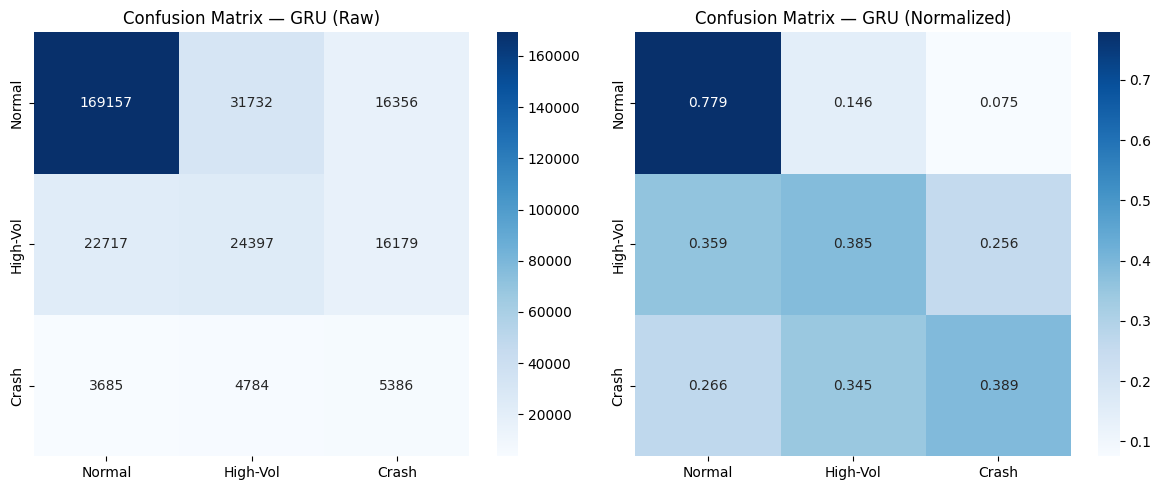

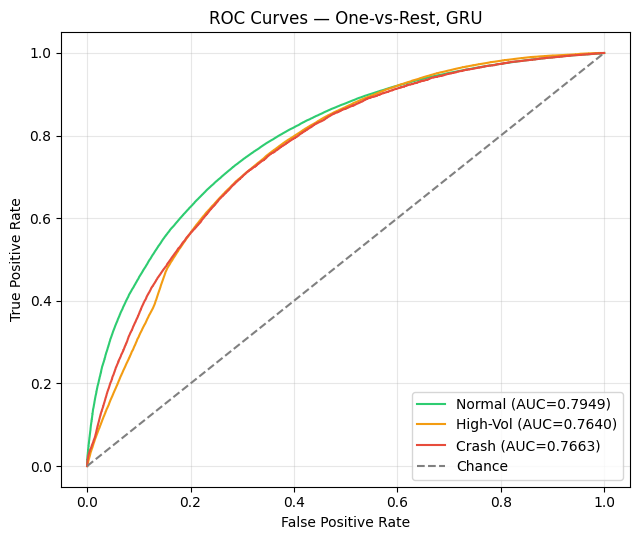


REPORT COMPLETE — GRU


In [ ]:
# ============================================================
# BLOCK 16-GRU — FINAL COMPREHENSIVE REPORT
# ============================================================
CLASS_ORDER = [0, 1, 2]
CLASS_LABELS_LIST = [CLASS_NAMES[c] for c in CLASS_ORDER]

model_params_gru = {k: v for k, v in best_params_gru.items() if k != "batch_size"}
batch_size_gru = best_params_gru.get("batch_size", 32)

print("="*70)
print("1. CLASSIFICATION REPORT (test set) — GRU")
print("="*70)
report_dict_gru = classification_report(y_test_seq, test_pred_gru, target_names=CLASS_LABELS_LIST,
                                         digits=4, output_dict=True)
print(pd.DataFrame(report_dict_gru).T.round(4))

print("\n" + "="*70)
print("2. CROSS-VALIDATION REPORT (mean ± std across folds) — GRU")
print("="*70)
per_fold_reports_gru = []
for i, (tr_idx, va_idx) in enumerate(cv_splits_seq):
    X_tr, y_tr = X_train_seq[tr_idx], y_train_seq[tr_idx]
    X_va, y_va = X_train_seq[va_idx], y_train_seq[va_idx]
    cw_fold = get_class_weight_dict(y_tr)
    model = build_gru(input_shape=(X_tr.shape[1], X_tr.shape[2]), **model_params_gru)
    es = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=20,
              batch_size=batch_size_gru, class_weight=cw_fold,
              callbacks=[es], verbose=0)
    va_pred = model.predict(X_va, verbose=0).argmax(axis=1)
    rep = classification_report(y_va, va_pred, target_names=CLASS_LABELS_LIST,
                                 digits=4, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df["fold"] = i + 1
    per_fold_reports_gru.append(rep_df)
    print(f"Fold {i+1} done")

all_folds_df_gru = pd.concat(per_fold_reports_gru).reset_index().rename(columns={"index": "class_metric"})
cv_summary_gru = all_folds_df_gru.groupby("class_metric")[["precision", "recall", "f1-score", "support"]].agg(["mean", "std"])
cv_summary_gru.columns = ["_".join(c) for c in cv_summary_gru.columns]
print(cv_summary_gru.round(4))

cm_raw_gru = confusion_matrix(y_test_seq, test_pred_gru)
cm_norm_gru = confusion_matrix(y_test_seq, test_pred_gru, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_raw_gru, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[0])
axes[0].set_title("Confusion Matrix — GRU (Raw)")
sns.heatmap(cm_norm_gru, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[1])
axes[1].set_title("Confusion Matrix — GRU (Normalized)")
plt.tight_layout(); plt.show()

y_test_bin = label_binarize(y_test_seq, classes=CLASS_ORDER)
plt.figure(figsize=(6.5, 5.5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba_gru[:, i])
    roc_auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{CLASS_NAMES[c]} (AUC={roc_auc_c:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest, GRU")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("REPORT COMPLETE — GRU")
print("="*70)